# Boosting

#### AdaBoost and Gradient Boosting via Sklearn
##### Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
##### Objective: Familiarize yourself with standard boosting algorithms and the concept of learning rates.
##### Task: Train an AdaBoostClassifier and a GradientBoostingClassifier on a structured dataset.
##### Requirements:
               - Create a grid search (GridSearchCV) to tune the learning_rate and n_estimators.               
               - Plot the relationship between the number of estimators and the training/validation error.
               - Question to answer: At what point does the Gradient Boosting model start to overfit, and how does the learning rate affect this point?

AdaBoost best params: {'learning_rate': 1.0, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       290
           1       0.96      0.89      0.93       104

    accuracy                           0.96       394
   macro avg       0.96      0.94      0.95       394
weighted avg       0.96      0.96      0.96       394

GradientBoosting best params: {'learning_rate': 0.5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       290
           1       0.95      0.89      0.92       104

    accuracy                           0.96       394
   macro avg       0.96      0.94      0.95       394
weighted avg       0.96      0.96      0.96       394



D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


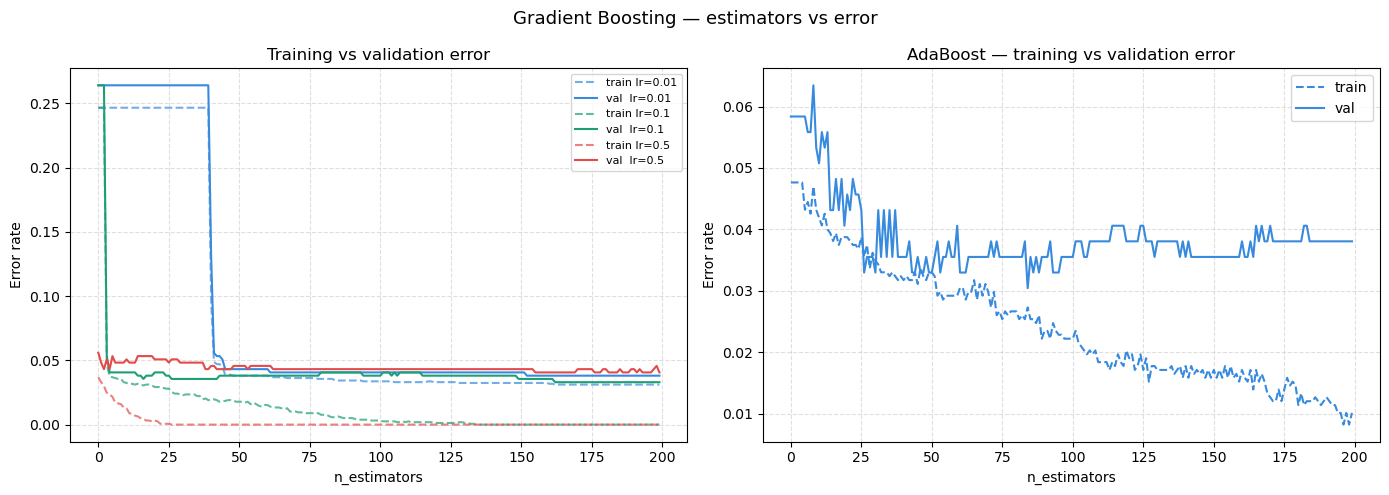

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv("creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]
fraud     = df[df.Class == 1]
non_fraud = df[df.Class == 0].sample(len(fraud) * 3, random_state=42)
df_bal    = pd.concat([fraud, non_fraud])
X = df_bal.drop("Class", axis=1)
y = df_bal["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ada = AdaBoostClassifier(random_state=42)
ada_params = {
    "n_estimators":  [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
}
ada_grid = GridSearchCV(ada, ada_params, cv=3, scoring="f1", n_jobs=-1)
ada_grid.fit(X_train, y_train)

print("AdaBoost best params:", ada_grid.best_params_)
ada_pred = ada_grid.predict(X_test)
print(classification_report(y_test, ada_pred))

gb = GradientBoostingClassifier(random_state=42)
gb_params = {
    "n_estimators":  [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5],
}
gb_grid = GridSearchCV(gb, gb_params, cv=3, scoring="f1", n_jobs=-1)
gb_grid.fit(X_train, y_train)

print("GradientBoosting best params:", gb_grid.best_params_)
gb_pred = gb_grid.predict(X_test)
print(classification_report(y_test, gb_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gradient Boosting — estimators vs error", fontsize=13)

learning_rates = [0.01, 0.1, 0.5]
colors         = ["#378ADD", "#1D9E75", "#E24B4A"]
n_est          = 200

for lr, color in zip(learning_rates, colors):
    model = GradientBoostingClassifier(n_estimators=n_est, learning_rate=lr, random_state=42)
    model.fit(X_train, y_train)

    train_errors = [1 - accuracy_score(y_train, p) for p in model.staged_predict(X_train)]
    val_errors   = [1 - accuracy_score(y_test,  p) for p in model.staged_predict(X_test)]

    axes[0].plot(train_errors, color=color, linestyle="--", alpha=0.7, label=f"train lr={lr}")
    axes[0].plot(val_errors,   color=color,                             label=f"val  lr={lr}")

axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("Error rate")
axes[0].set_title("Training vs validation error")
axes[0].legend(fontsize=8)
axes[0].grid(linestyle="--", alpha=0.4)

ada_best = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=ada_grid.best_params_["learning_rate"],
    random_state=42
)
ada_best.fit(X_train, y_train)

ada_train_err = [1 - accuracy_score(y_train, p) for p in ada_best.staged_predict(X_train)]
ada_val_err   = [1 - accuracy_score(y_test,  p) for p in ada_best.staged_predict(X_test)]

axes[1].plot(ada_train_err, "--", color="#378ADD", label="train")
axes[1].plot(ada_val_err,         color="#378ADD", label="val")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Error rate")
axes[1].set_title("AdaBoost — training vs validation error")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

#### Extreme Gradient Boosting (XGBoost/LightGBM)
##### Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
##### Objective: Utilize industry-standard libraries to handle real-world challenges like class imbalance and early stopping.
##### Task: Use the xgboost or lightgbm library on a highly imbalanced dataset (e.g., Credit Card Fraud Detection).
##### Requirements:
             - Implement Early Stopping by using a dedicated validation set during the training loop to halt training when validation log-loss stops improving.             
             - Handle the class imbalance using the scale_pos_weight parameter or by utilizing focal loss.
             - Use SHAP (SHapley Additive exPlanations) values to interpret the most important features driving the model's predictions.

scale_pos_weight: 559.0
[0]	validation_0-logloss:0.64884	validation_1-logloss:0.64880
[50]	validation_0-logloss:0.06120	validation_1-logloss:0.06155
[100]	validation_0-logloss:0.01463	validation_1-logloss:0.01531
[150]	validation_0-logloss:0.00571	validation_1-logloss:0.00659
[200]	validation_0-logloss:0.00228	validation_1-logloss:0.00359
[250]	validation_0-logloss:0.00104	validation_1-logloss:0.00278
[300]	validation_0-logloss:0.00048	validation_1-logloss:0.00255
[350]	validation_0-logloss:0.00024	validation_1-logloss:0.00251

Best iteration: 330

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     42663
           1       0.85      0.90      0.88        59

    accuracy                           1.00     42722
   macro avg       0.93      0.95      0.94     42722
weighted avg       1.00      1.00      1.00     42722

ROC-AUC: 0.9851


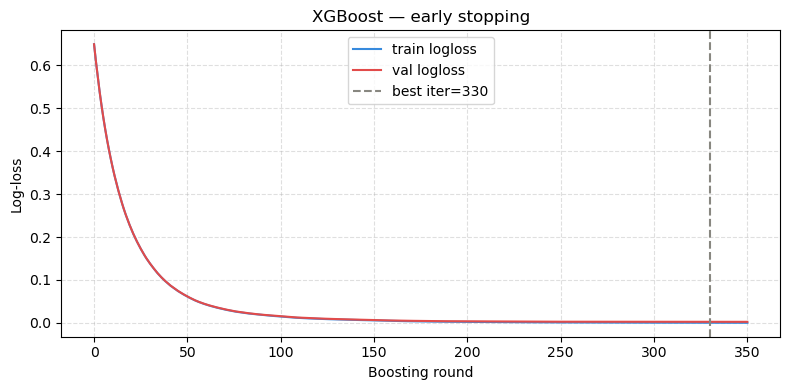

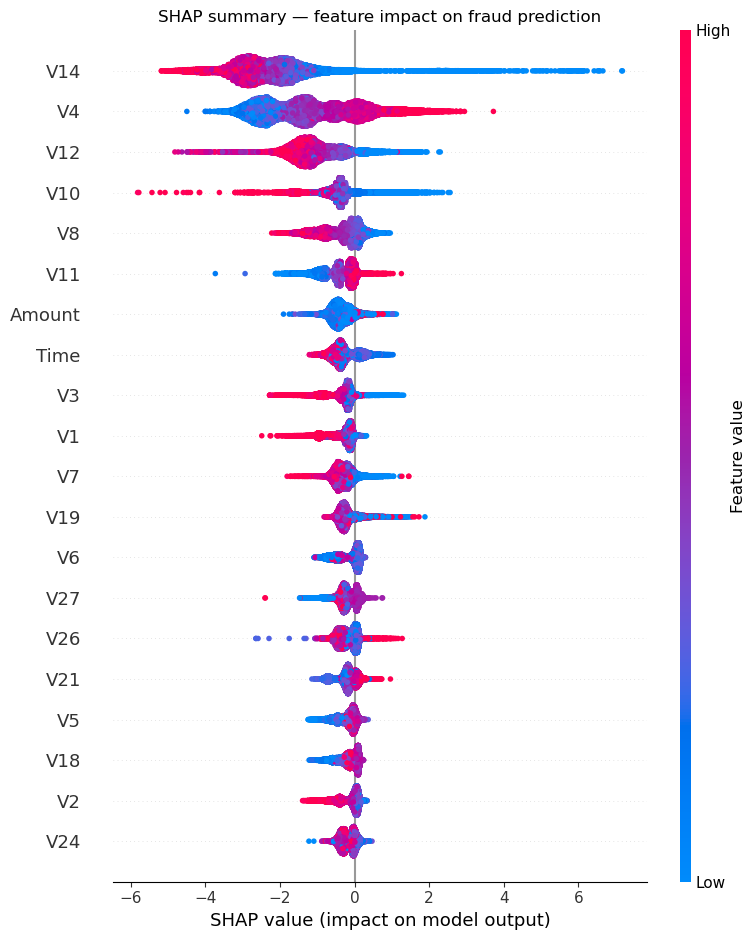

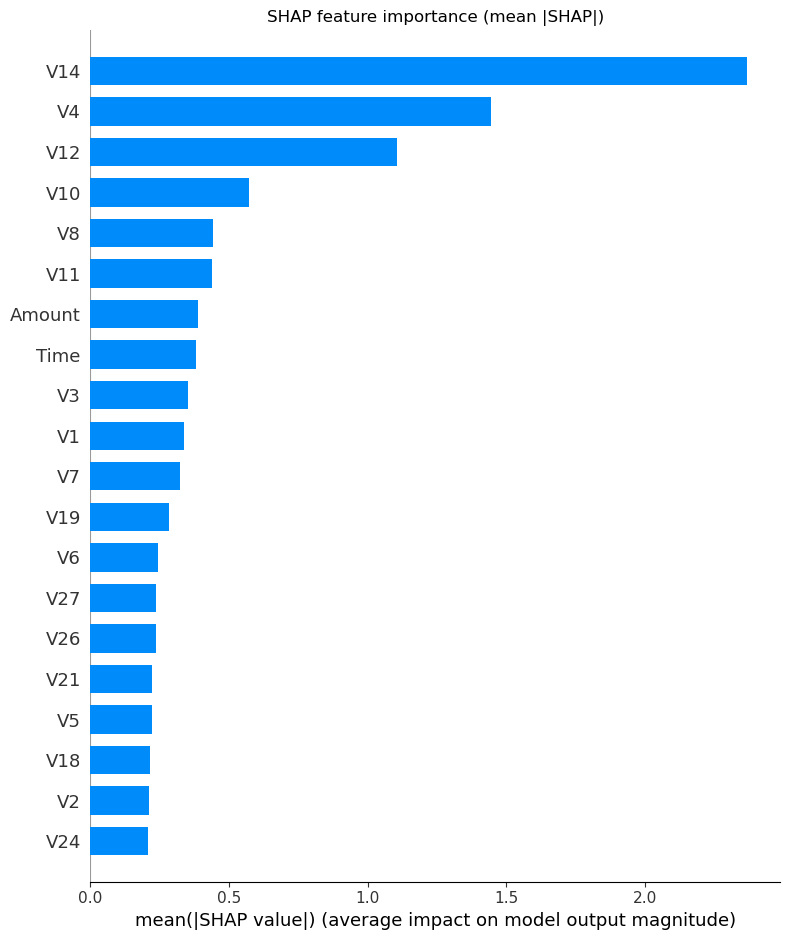

In [17]:
!pip install xgboost shap
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

df = pd.read_csv("creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

model = xgb.XGBClassifier(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = "logloss",
    early_stopping_rounds = 20,
    random_state          = 42,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_val, y_val)],
    verbose  = 50,
)

print(f"\nBest iteration: {model.best_iteration}")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n", classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

results    = model.evals_result()
train_loss = results["validation_0"]["logloss"]
val_loss   = results["validation_1"]["logloss"]

plt.figure(figsize=(8, 4))
plt.plot(train_loss, label="train logloss", color="#378ADD")
plt.plot(val_loss,   label="val logloss",   color="#E24B4A")
plt.axvline(model.best_iteration, linestyle="--", color="#888780", label=f"best iter={model.best_iteration}")
plt.xlabel("Boosting round")
plt.ylabel("Log-loss")
plt.title("XGBoost — early stopping")
plt.legend()
plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP summary — feature impact on fraud prediction")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP feature importance (mean |SHAP|)")
plt.tight_layout()
plt.show()